# Experiment 5 – Unsupervised Learning
**ENCS5141 – Machine Learning and Data Science**  
Birzeit University

---

This notebook covers:
- K-Means Clustering
- DBSCAN Clustering
- Gaussian Mixture Models (GMM)
- Quantitative Evaluation of Clustering Methods
- **ToDo 1:** Two Moons Dataset
- **ToDo 2:** K-Means vs K-Medoids
- **ToDo 3:** Image Segmentation with K-Means

## 0. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn import metrics
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

---
## 1. Data Generation – Blobs

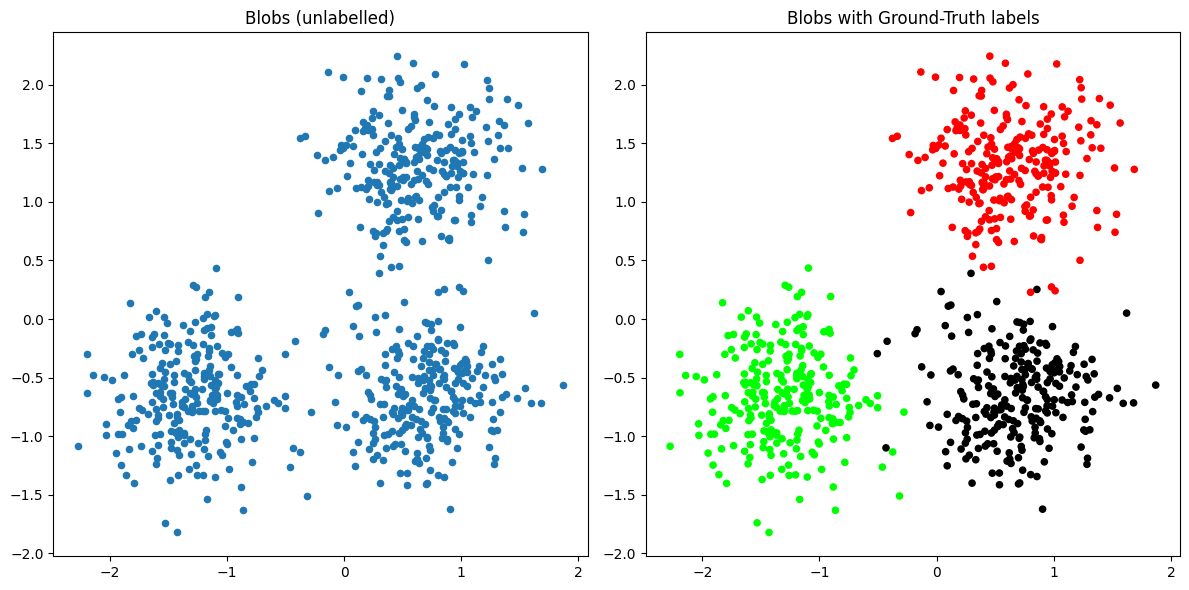

In [ ]:
# ── Generate a Gaussian 2D dataset (blobs) ──────────────────────────────────
centers = [[1, 1], [-1, -1], [1, -1]]
X_blobs, labels_blobs = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0)
X_blobs = StandardScaler().fit_transform(X_blobs)

colormap = np.array(['red', 'lime', 'black'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=20)
plt.title('Blobs (unlabelled)')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=20)
plt.title('Blobs with Ground-Truth labels')

plt.tight_layout()
plt.show()

---
## 2. K-Means Clustering on Blobs

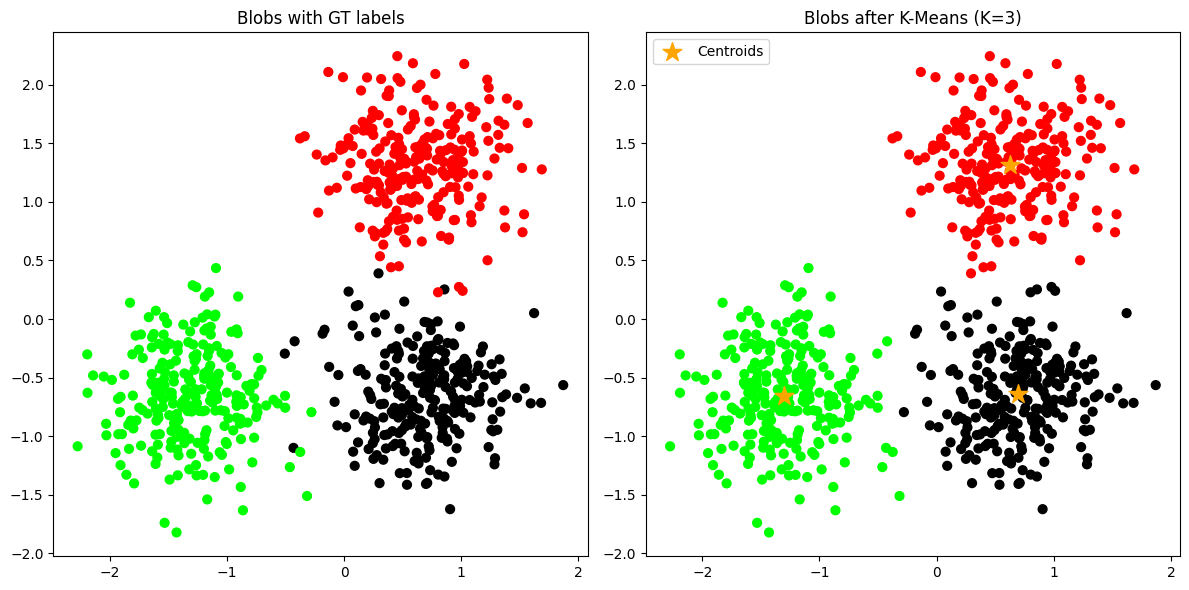

In [ ]:
# ── Fit KMeans with K = 3 ───────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_blobs)
predY_kmeans = np.choose(kmeans.labels_, [0, 1, 2]).astype(np.int64)
k_means_cluster_centers = kmeans.cluster_centers_

# ── Visualise ───────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=40)
plt.title('Blobs with GT labels')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[predY_kmeans], s=40)
plt.scatter(k_means_cluster_centers[:, 0],
            k_means_cluster_centers[:, 1],
            marker='*', c='orange', s=200, zorder=5, label='Centroids')
plt.legend()
plt.title('Blobs after K-Means (K=3)')

plt.tight_layout()
plt.show()

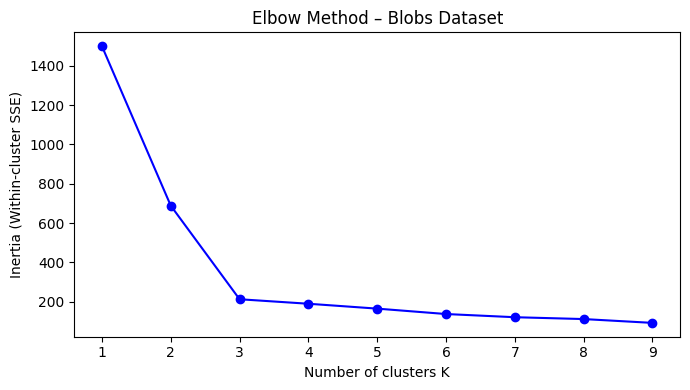

In [ ]:
# ── Try different values of K (Elbow method) ────────────────────────────────
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method – Blobs Dataset')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

---
## 3. DBSCAN Clustering on Blobs

In [ ]:
# ── Fit DBSCAN ──────────────────────────────────────────────────────────────
db = DBSCAN(eps=0.3, min_samples=10).fit(X_blobs)
labels_db = db.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db   = list(labels_db).count(-1)
print(f"Estimated number of clusters : {n_clusters_db}")
print(f"Estimated number of noise pts: {n_noise_db}")

Estimated number of clusters : 3
Estimated number of noise pts: 18


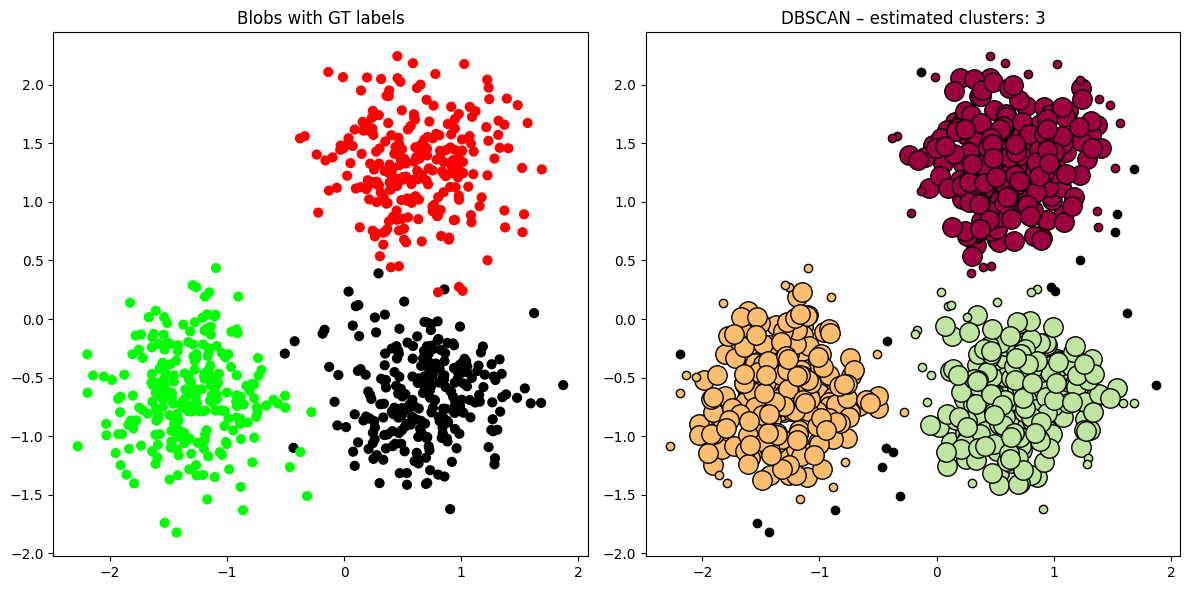

In [ ]:
# ── Visualise ───────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=40)
plt.title('Blobs with GT labels')

plt.subplot(1, 2, 2)
unique_labels = set(labels_db)
core_mask = np.zeros_like(labels_db, dtype=bool)
core_mask[db.core_sample_indices_] = True
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # noise → black
    mask = labels_db == k
    # core points – large markers
    xy = X_blobs[mask & core_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o',
             markerfacecolor=tuple(col), markeredgecolor='k', markersize=14)
    # border / noise points – small markers
    xy = X_blobs[mask & ~core_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o',
             markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)

plt.title(f'DBSCAN – estimated clusters: {n_clusters_db}')
plt.tight_layout()
plt.show()

---
## 4. Gaussian Mixture Model (GMM) on Blobs

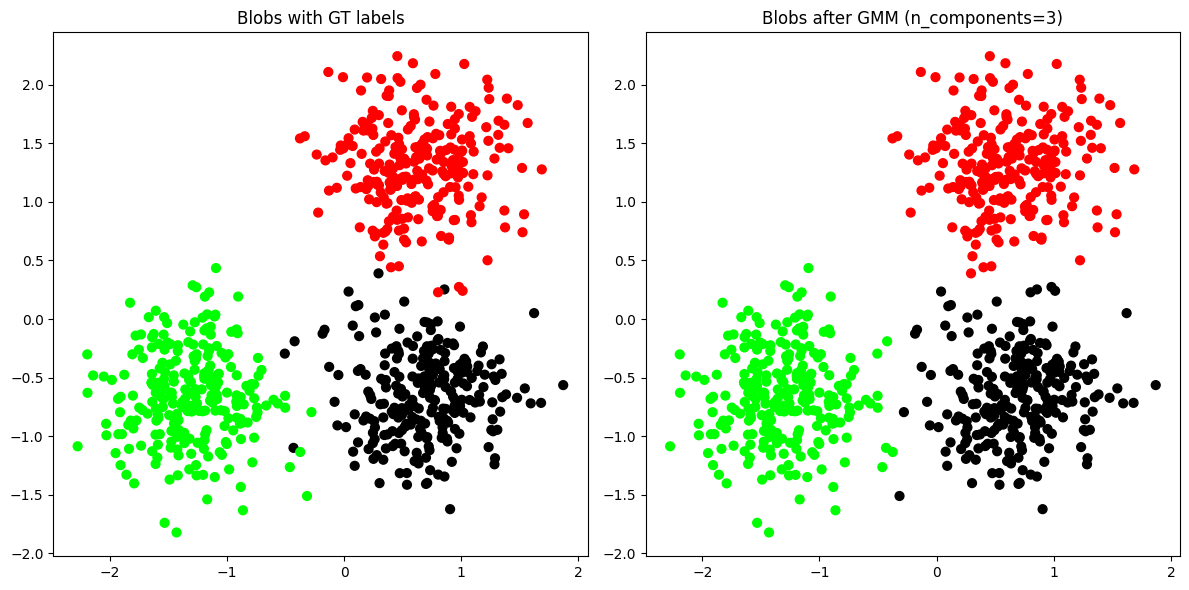

In [ ]:
# ── Fit GMM ─────────────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(X_blobs)
y_gmm = gmm.predict(X_blobs)

# ── Visualise ───────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[labels_blobs], s=40)
plt.title('Blobs with GT labels')

plt.subplot(1, 2, 2)
plt.scatter(X_blobs[:, 0], X_blobs[:, 1],
            c=colormap[y_gmm], s=40)
plt.title('Blobs after GMM (n_components=3)')

plt.tight_layout()
plt.show()

---
## 5. Quantitative Evaluation – Blobs Dataset

In [ ]:
def evaluate_clustering(name, true_labels, pred_labels, X):
    """Print clustering evaluation metrics."""
    print(f"{'─'*40}")
    print(f"{name} – Evaluation Metrics\n")
    print(f"  Homogeneity       : {metrics.homogeneity_score(true_labels, pred_labels):.3f}")
    print(f"  Completeness      : {metrics.completeness_score(true_labels, pred_labels):.3f}")
    print(f"  V-measure         : {metrics.v_measure_score(true_labels, pred_labels):.3f}")
    print(f"  Adj. Rand Index   : {metrics.adjusted_rand_score(true_labels, pred_labels):.3f}")
    print(f"  Adj. Mutual Info  : {metrics.adjusted_mutual_info_score(true_labels, pred_labels):.3f}")
    # Silhouette requires at least 2 clusters; skip for degenerate cases
    unique_preds = len(set(pred_labels)) - (1 if -1 in pred_labels else 0)
    if unique_preds >= 2:
        mask = pred_labels != -1          # exclude noise for DBSCAN
        sil = metrics.silhouette_score(X[mask], pred_labels[mask])
        print(f"  Silhouette Score  : {sil:.3f}")
    else:
        print(f"  Silhouette Score  : N/A (only {unique_preds} cluster)")
    print()

evaluate_clustering("DBSCAN",   labels_blobs, labels_db,     X_blobs)
evaluate_clustering("K-Means",  labels_blobs, predY_kmeans,  X_blobs)
evaluate_clustering("GMM",      labels_blobs, y_gmm,         X_blobs)

────────────────────────────────────────
DBSCAN – Evaluation Metrics

  Homogeneity       : 0.953
  Completeness      : 0.883
  V-measure         : 0.917
  Adj. Rand Index   : 0.952
  Adj. Mutual Info  : 0.916
  Silhouette Score  : 0.664

────────────────────────────────────────
K-Means – Evaluation Metrics

  Homogeneity       : 0.945
  Completeness      : 0.945
  V-measure         : 0.945
  Adj. Rand Index   : 0.968
  Adj. Mutual Info  : 0.945
  Silhouette Score  : 0.650

────────────────────────────────────────
GMM – Evaluation Metrics

  Homogeneity       : 0.939
  Completeness      : 0.939
  V-measure         : 0.939
  Adj. Rand Index   : 0.964
  Adj. Mutual Info  : 0.938
  Silhouette Score  : 0.650



---
## ToDo 1 – Two Moons Dataset

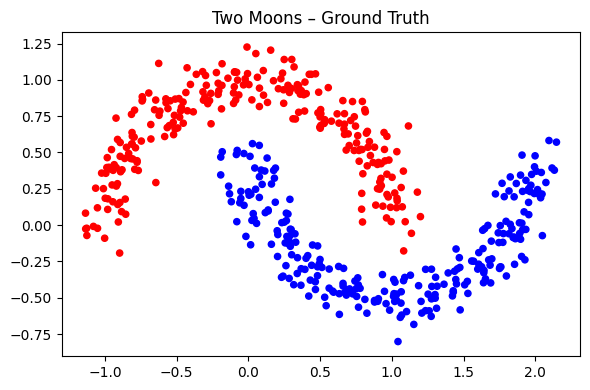

In [ ]:
# ── Generate Two Moons ──────────────────────────────────────────────────────
X_moons, labels_moons = make_moons(n_samples=500, noise=0.1, random_state=0)
colormap2 = np.array(['red', 'blue'])

plt.figure(figsize=(6, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1],
            c=colormap2[labels_moons], s=20)
plt.title('Two Moons – Ground Truth')
plt.tight_layout()
plt.show()

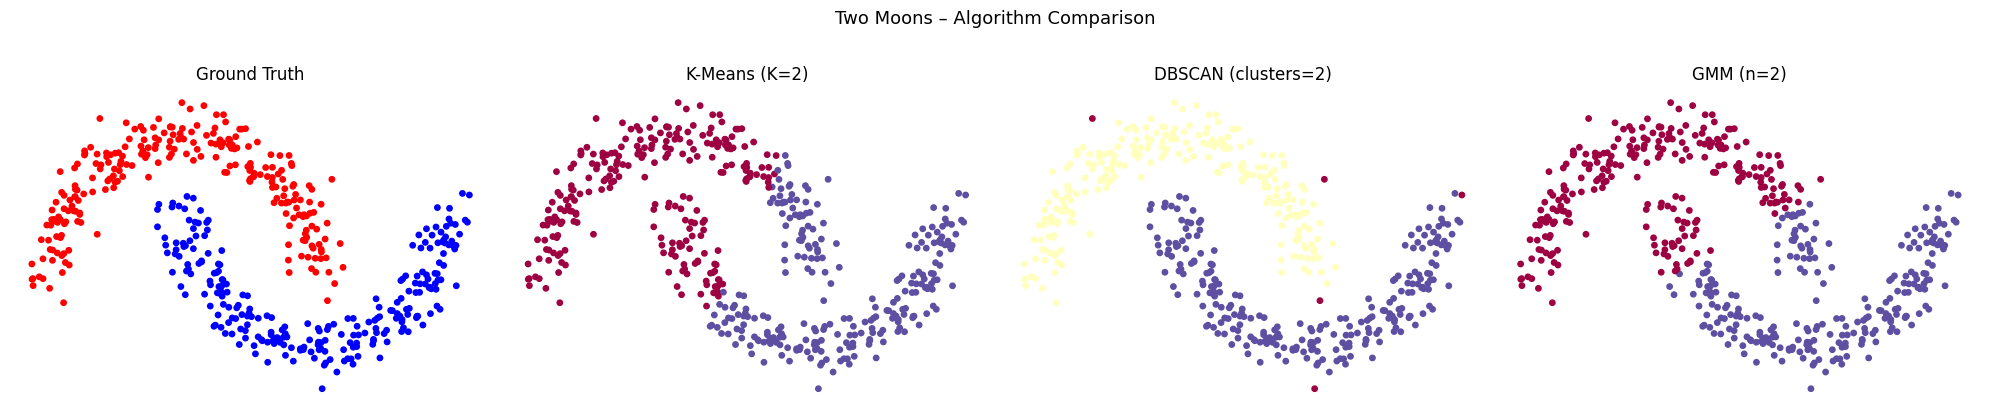

In [ ]:
# ── K-Means on Two Moons (K = 2) ────────────────────────────────────────────
km_moons = KMeans(n_clusters=2, random_state=0)
km_moons.fit(X_moons)
pred_km_moons = km_moons.labels_

# ── DBSCAN on Two Moons ─────────────────────────────────────────────────────
db_moons = DBSCAN(eps=0.15, min_samples=5).fit(X_moons)
labels_db_moons = db_moons.labels_
n_clusters_moons = len(set(labels_db_moons)) - (1 if -1 in labels_db_moons else 0)

# ── GMM on Two Moons (n_components = 2) ────────────────────────────────────
gmm_moons = GaussianMixture(n_components=2, random_state=0)
gmm_moons.fit(X_moons)
pred_gmm_moons = gmm_moons.predict(X_moons)

# ── Visualise ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles  = ['Ground Truth', 'K-Means (K=2)',
           f'DBSCAN (clusters={n_clusters_moons})', 'GMM (n=2)']
results = [labels_moons, pred_km_moons, labels_db_moons, pred_gmm_moons]
cmaps   = [colormap2, colormap2,
           plt.cm.Spectral(np.linspace(0, 1, len(set(labels_db_moons)))),
           colormap2]

for ax, title, pred in zip(axes, titles, results):
    unique_vals = sorted(set(pred))
    palette = plt.cm.Spectral(np.linspace(0, 1, len(unique_vals)))
    color_arr = np.array([palette[unique_vals.index(p)] for p in pred])
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=color_arr, s=15)
    ax.set_title(title)
    ax.axis('off')

# Override GT plot with proper 2-color
axes[0].cla()
axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=colormap2[labels_moons], s=15)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

plt.suptitle('Two Moons – Algorithm Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Quantitative: Two Moons ─────────────────────────────────────────────────
print("\n=== Two Moons Dataset ===")
evaluate_clustering("K-Means",  labels_moons, pred_km_moons,    X_moons)
evaluate_clustering("DBSCAN",   labels_moons, labels_db_moons,  X_moons)
evaluate_clustering("GMM",      labels_moons, pred_gmm_moons,   X_moons)


=== Two Moons Dataset ===
────────────────────────────────────────
K-Means – Evaluation Metrics

  Homogeneity       : 0.192
  Completeness      : 0.192
  V-measure         : 0.192
  Adj. Rand Index   : 0.253
  Adj. Mutual Info  : 0.191
  Silhouette Score  : 0.484

────────────────────────────────────────
DBSCAN – Evaluation Metrics

  Homogeneity       : 0.990
  Completeness      : 0.925
  V-measure         : 0.956
  Adj. Rand Index   : 0.980
  Adj. Mutual Info  : 0.956
  Silhouette Score  : 0.325

────────────────────────────────────────
GMM – Evaluation Metrics

  Homogeneity       : 0.375
  Completeness      : 0.375
  V-measure         : 0.375
  Adj. Rand Index   : 0.472
  Adj. Mutual Info  : 0.374
  Silhouette Score  : 0.468



### Observation – Blobs vs Two Moons

| Dataset | Best Algorithm | Why |
|---------|---------------|-----|
| Blobs   | K-Means / GMM | Convex, roughly spherical, equal-density clusters — exactly the assumption K-Means makes |
| Two Moons | DBSCAN | Non-convex, crescent-shaped clusters — K-Means and GMM fail because they assume elliptical boundaries; DBSCAN uses local density and discovers arbitrary shapes |

K-Means and GMM partition the moons by a linear/elliptical boundary, assigning the overlapping zone incorrectly.  
DBSCAN, with `eps=0.15, min_samples=5`, traces the curved manifold of each moon.

---
## ToDo 2 – K-Means vs K-Medoids (Blobs Dataset)

In [ ]:
# ── Install scikit-learn-extra ───────────────────────────────────────────────
!pip install scikit-learn-extra -q
try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_AVAILABLE = True
except ImportError:
    KMEDOIDS_AVAILABLE = False
    print("scikit-learn-extra not found. Run: pip install scikit-learn-extra")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 9.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
scikit-learn-extra not found. Run: pip install scikit-learn-extra



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

In [ ]:
if KMEDOIDS_AVAILABLE:
    # ── Fit K-Medoids ────────────────────────────────────────────────────────
    kmedoids = KMedoids(n_clusters=3, random_state=0)
    kmedoids.fit(X_blobs)
    pred_kmed = kmedoids.labels_
    medoid_centers = kmedoids.cluster_centers_

    # ── Visualise ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Ground truth
    axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1],
                    c=colormap[labels_blobs], s=30)
    axes[0].set_title('Ground Truth')

    # K-Means
    axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1],
                    c=colormap[predY_kmeans], s=30)
    axes[1].scatter(k_means_cluster_centers[:, 0],
                    k_means_cluster_centers[:, 1],
                    marker='*', c='orange', s=200, zorder=5, label='Centroids')
    axes[1].legend()
    axes[1].set_title('K-Means (K=3)')

    # K-Medoids
    axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1],
                    c=colormap[pred_kmed], s=30)
    axes[2].scatter(medoid_centers[:, 0], medoid_centers[:, 1],
                    marker='D', c='cyan', s=150, zorder=5, label='Medoids')
    axes[2].legend()
    axes[2].set_title('K-Medoids (K=3)')

    plt.suptitle('K-Means vs K-Medoids – Blobs', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── Quantitative comparison ───────────────────────────────────────────────
    print("\n=== Blobs: K-Means vs K-Medoids ===")
    evaluate_clustering("K-Means",   labels_blobs, predY_kmeans, X_blobs)
    evaluate_clustering("K-Medoids", labels_blobs, pred_kmed,    X_blobs)

### Observation – K-Means vs K-Medoids

| Property | K-Means | K-Medoids |
|----------|---------|----------|
| Center | Virtual centroid (mean) | Actual data point (medoid) |
| Objective | Minimize sum of squared Euclidean distances | Minimize sum of dissimilarities |
| Outlier sensitivity | High – mean shifts toward outliers | Lower – medoid is a real point, less affected |
| Distance metric | Euclidean (by default) | Any distance metric |
| Computational cost | O(nkt) – faster | O(n²k) – slower on large datasets |

On well-separated Gaussian blobs both methods perform similarly.  
K-Medoids becomes preferable when the dataset contains outliers or non-Euclidean distances are needed.

---
## ToDo 3 – Image Segmentation with K-Means

In [ ]:
# ── Load your own image ─────────────────────────────────────────────────────
# Replace the path below with your own image path.
# If running in Jupyter, you can also use:
#   from google.colab import files; uploaded = files.upload()

IMAGE_PATH = 'your_image.jpg'   # <-- change this

try:
    img = Image.open(IMAGE_PATH).convert('RGB')
    img_array = np.array(img)           # shape: (H, W, 3)
    print(f"Image loaded: {img_array.shape}")
except FileNotFoundError:
    # Fallback: generate a small synthetic colour image for demonstration
    print("Image not found – using a synthetic demo image.")
    from sklearn.datasets import load_sample_image
    img_array = load_sample_image('china.jpg')   # bundled with sklearn
    img = Image.fromarray(img_array)

Image not found – using a synthetic demo image.


In [ ]:
def segment_image(image_array, k, random_state=42):
    """
    Segment a colour image into k clusters using K-Means.
    Returns the segmented image (same shape as input).
    """
    H, W, C = image_array.shape
    # Flatten pixels: (H*W, 3)
    pixels = image_array.reshape(-1, 3).astype(np.float32)

    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    km.fit(pixels)

    # Replace each pixel with its cluster centroid colour
    segmented_pixels = km.cluster_centers_[km.labels_]
    segmented_image  = segmented_pixels.reshape(H, W, C).astype(np.uint8)
    return segmented_image, km

K=2 done.
K=5 done.
K=10 done.


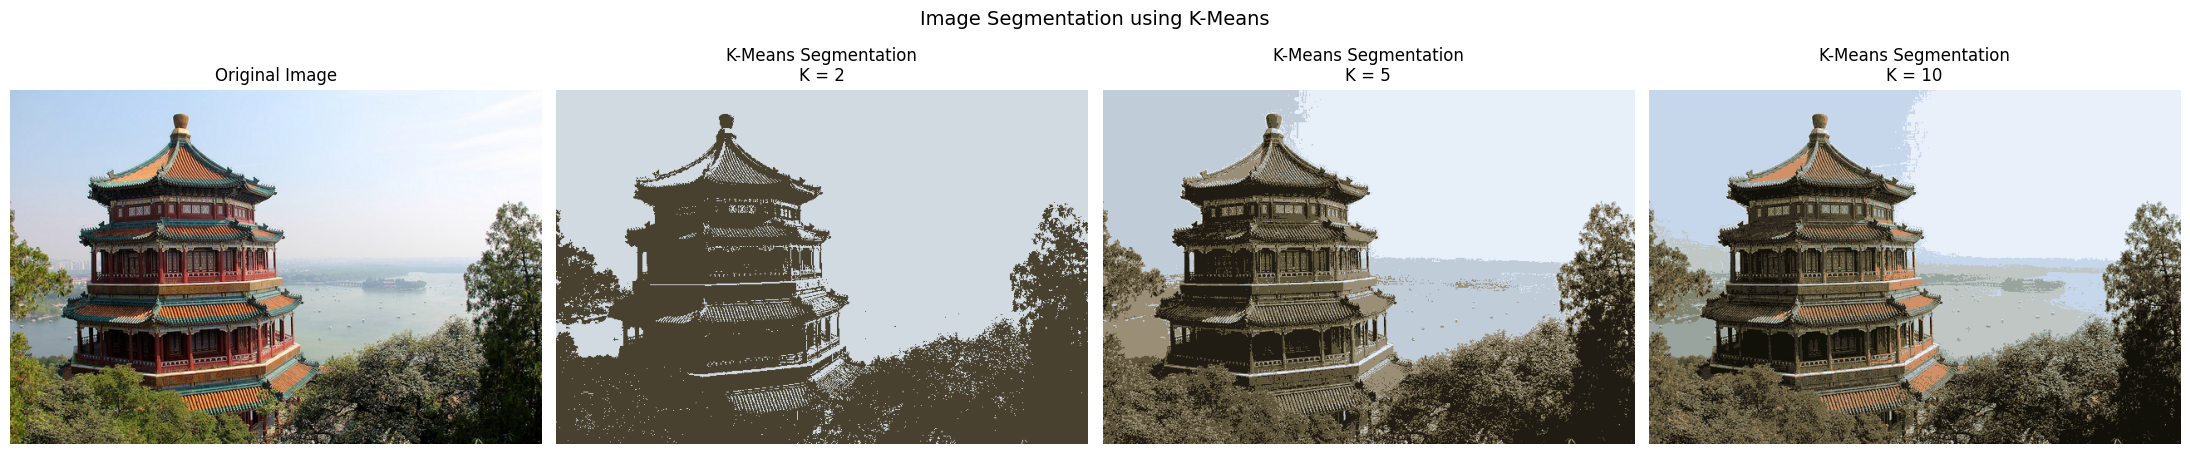

In [ ]:
K_values = [2, 5, 10]
segmented_images = {}

for k in K_values:
    seg_img, km_model = segment_image(img_array, k)
    segmented_images[k] = seg_img
    print(f"K={k} done.")

# ── Display ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_array)
axes[0].set_title('Original Image')
axes[0].axis('off')

for ax, k in zip(axes[1:], K_values):
    ax.imshow(segmented_images[k])
    ax.set_title(f'K-Means Segmentation\nK = {k}')
    ax.axis('off')

plt.suptitle('Image Segmentation using K-Means', fontsize=14)
plt.tight_layout()
plt.show()